In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\HP\Desktop\csv3.csv")

df.shape
df.dtypes
df.isnull().sum()

Ship Mode         0
Sales             0
Quantity          0
Profit            0
Discount          0
Order Priority    0
Category          0
Sub-Category      0
Segment           0
Market            0
Region            0
Country           0
Row ID            0
dtype: int64

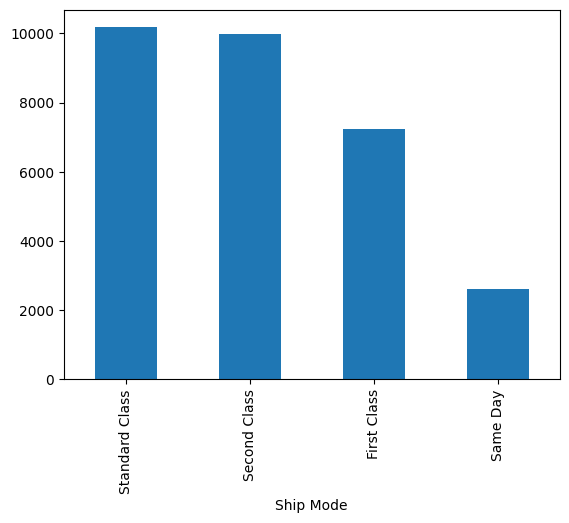

In [8]:
df['Ship Mode'].value_counts()

df['Ship Mode'].value_counts().plot(kind='bar')
plt.show()

In [9]:
df.describe()

,Sales,Quantity,Profit,Discount,Row ID
count,30000.000000,30000.000000,30000.00000,30000.000000,30000.000000
mean,168.542630,3.143067,18.67745,0.160325,26697.639500
std,403.419643,2.125829,140.60771,0.228033,15098.427954
min,0.440000,1.000000,-3839.99000,0.000000,1.000000
25%,18.660000,2.000000,-0.99000,0.000000,13155.500000
50%,38.740000,3.000000,5.40000,0.000000,28139.500000
75%,135.640000,4.000000,18.00000,0.200000,39769.250000
max,14000.000000,14.000000,6719.98000,0.850000,51290.000000


In [10]:
df.corr(numeric_only=True)

,Sales,Quantity,Profit,Discount,Row ID
Sales,1.000000,0.325093,0.493694,-0.091132,-0.050287
Quantity,0.325093,1.000000,0.112238,-0.016198,-0.182424
Profit,0.493694,0.112238,1.000000,-0.277150,-0.017348
Discount,-0.091132,-0.016198,-0.277150,1.000000,0.103561
Row ID,-0.050287,-0.182424,-0.017348,0.103561,1.000000


In [11]:
categorical_cols = ['Order Priority', 'Category', 'Sub-Category', 'Segment', 'Market', 'Region', 'Country']

for col in categorical_cols:
    print(col, df[col].nunique())

Order Priority 4
Category 3
Sub-Category 17
Segment 3
Market 7
Region 13
Country 144


In [12]:
feature_cols = ['Sales', 'Quantity', 'Profit', 'Discount']
categorical_cols = ['Order Priority', 'Category', 'Sub-Category', 'Segment', 'Market', 'Region']

df_encoded = pd.get_dummies(df[categorical_cols], dtype=int)

X = pd.concat([df[feature_cols], df_encoded], axis=1)
y = df['Ship Mode']

X.shape
X.head()

,Sales,Quantity,Profit,Discount,Order Priority_Critical,Order Priority_High,Order Priority_Low,Order Priority_Medium,Category_Furniture,Category_Office Supplies,...,Region_Central,Region_Central Asia,Region_EMEA,Region_East,Region_North,Region_North Asia,Region_Oceania,Region_South,Region_Southeast Asia,Region_West
0,0.98,2,-1.48,0.8,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0
1,0.99,1,0.44,0.0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1.19,2,-0.99,0.7,1,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,0
3,1.25,3,-1.93,0.8,0,0,0,1,0,1,...,1,0,0,0,0,0,0,0,0,0
4,1.39,2,-3.76,0.8,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.75, random_state=0, stratify=y
)

X_train.shape
X_test.shape

(6000, 51)

In [19]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=0, k_neighbors=5)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

y_train_res.value_counts()

C:\Users\HP\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Ship Mode
Second Class      8141
Same Day          8141
Standard Class    8141
First Class       8141
Name: count, dtype: int64

In [20]:
model_dec_tree_sm = DecisionTreeClassifier(criterion='gini', max_depth=8, random_state=0)
model_dec_tree_sm.fit(X_train_res, y_train_res)

y_pred_sm = model_dec_tree_sm.predict(X_test)

accuracy_sm = accuracy_score(y_test, y_pred_sm)
print(f'Accuracy:\t{round(accuracy_sm, 3)}')

print(classification_report(y_test, y_pred_sm))

Accuracy:	0.574
                precision    recall  f1-score   support

   First Class       0.43      0.28      0.34      1446
      Same Day       0.23      0.05      0.08       524
  Second Class       0.55      0.50      0.52      1995
Standard Class       0.65      0.99      0.78      2035

      accuracy                           0.57      6000
     macro avg       0.46      0.46      0.43      6000
  weighted avg       0.52      0.57      0.53      6000



In [22]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_rf.feature_importances_
})

feature_importance_sorted = feature_importance.sort_values(by='importance', ascending=False)
feature_importance_sorted.head(10)

,feature,importance
0,Sales,0.250620
7,Order Priority_Medium,0.150312
2,Profit,0.099259
5,Order Priority_High,0.043263
4,Order Priority_Critical,0.039744
6,Order Priority_Low,0.039651
1,Quantity,0.034861
9,Category_Office Supplies,0.028905
3,Discount,0.028705
29,Segment_Corporate,0.023953


In [27]:
X_train_res['Sales_log'] = np.log(X_train_res['Sales'] + 1)
X_test['Sales_log'] = np.log(X_test['Sales'] + 1)

In [35]:
df2 = pd.read_csv(r"C:\Users\HP\Desktop\csv4.csv")

df2.shape
df2.dtypes
df2.isnull().sum()

Ship Mode         0
Sales             0
Quantity          0
Profit            0
Discount          0
Order Priority    0
Category          0
Sub-Category      0
Segment           0
Market            0
Region            0
Country           0
Row ID            0
Customer Key      0
Day Name          0
Month Name        0
Is Weekend        0
dtype: int64

In [36]:
feature_cols = ['Sales', 'Quantity', 'Profit', 'Discount', 'Customer Key']
categorical_cols = ['Order Priority', 'Category', 'Sub-Category', 'Segment', 'Market', 'Region', 'Day Name', 'Month Name', 'Is Weekend']

df2_encoded = pd.get_dummies(df2[categorical_cols], dtype=int)

X2 = pd.concat([df2[feature_cols], df2_encoded], axis=1)
y2 = df2['Ship Mode']

X2.shape

(30000, 72)

In [42]:
feature_importance2 = pd.DataFrame({
    'feature': X2.columns,
    'importance': model_rf2.feature_importances_
})

feature_importance2_sorted = feature_importance2.sort_values(by='importance', ascending=False)
feature_importance2_sorted.head(10)

,feature,importance
0,Sales,0.205797
9,Order Priority_Medium,0.144584
2,Profit,0.076294
4,Customer Key,0.037053
8,Order Priority_Low,0.037045
11,Category_Office Supplies,0.035322
6,Order Priority_Critical,0.031815
7,Order Priority_High,0.031471
3,Discount,0.022485
1,Quantity,0.021673
